<a href="https://colab.research.google.com/github/machiwao/CCDATSCL_EXERCISES_COM222-ML/blob/main/Exercise5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 5

In [1]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import chi2_contingency

## Part 1: ANOVA

A teacher wants to investigate whether different teaching methods affect students’ exam scores. The dataset contains 50 students, each assigned to one of three teaching methods (A, B, or C).

Question: "Is there a difference in mean exam scores among students taught using three different teaching methods?"

- Independent variable (factor): Teaching Method (A, B, C)
- Dependent variable: Exam Score (numeric)

In [2]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/exam_scores.csv?raw=true"

df_exam_scores = pd.read_csv(url)
df_exam_scores


,StudentID,Method,Score
0,1,A,79
1,2,A,77
2,3,A,82
3,4,A,75
4,5,A,80
5,6,A,78
6,7,A,83
7,8,A,76
8,9,A,81
9,10,A,74


Calculate the number of students in each teaching method.

In [12]:
# put your answer here
df_exam_scores.groupby('Method')['StudentID'].count()

,StudentID
Method,
A,17
B,17
C,16


Compute the mean and standard deviation of exam scores for each group.

In [11]:
# put your answer here
df_exam_scores.groupby('Method')['Score'].agg(['mean', 'std'])

,mean,std
Method,,
A,78.588235,2.575336
B,86.294118,2.365500
C,71.937500,1.768945


Use a plot to show the exam scores by teaching method.

<Axes: xlabel='Method'>

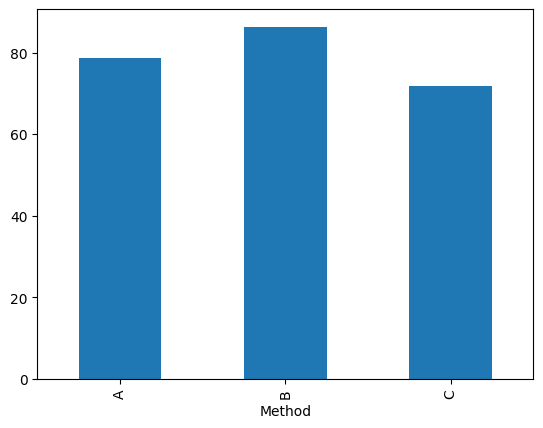

In [10]:
# put your answer here
# Use a plot to show the mean exam scores by teaching method
df_exam_scores.groupby('Method')['Score'].mean().plot(kind='bar')

Perform the ANOVA Test
- Use scipy.stats.f_oneway to conduct a one-way ANOVA.
- Report the F-statistic and p-value.
- Using a significance level of α = 0.05, state whether you reject or fail to reject H₀.

In [13]:
# put your answer here
f_statistic, p_value = stats.f_oneway(df_exam_scores[df_exam_scores['Method'] == 'A']['Score'],
                                      df_exam_scores[df_exam_scores['Method'] == 'B']['Score'],
                                      df_exam_scores[df_exam_scores['Method'] == 'C']['Score'])

# Report the F-statistic and p-value
print("F-statistic:", f_statistic)
print("p-value:", p_value)

F-statistic: 165.17845596593054
p-value: 5.5032645988699085e-22


Interpret the results. What does it say about the relationship between teaching method and exam scores?

In [16]:
# put your answer here
if p_value < 0.05:
    print("Reject the null hypothesis. There is a significant difference in mean exam scores among students taught using three different teaching methods (at α = 0.05).")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in mean exam scores among students taught using three different teaching methods (at α = 0.05).")

Reject the null hypothesis. There is a significant difference in mean exam scores among students taught using three different teaching methods (at α = 0.05).


## Part 2: Chi-squared

A survey was conducted to see if there is a relationship between gender and littering behavior.

Question:
"Is gender associated with littering behavior?"

Each row represents one person.

In [17]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/litteringdata.csv?raw=true"

df_littering_data = pd.read_csv(url)
df_littering_data

,ID,Gender,Litter
0,1,Male,Yes
1,2,Male,Yes
2,3,Male,Yes
3,4,Male,Yes
4,5,Male,Yes
5,6,Male,Yes
6,7,Male,Yes
7,8,Male,Yes
8,9,Male,Yes
9,10,Male,Yes


Count the number of observations in each category for Gender and Litter separately.

In [19]:
# put your answer here
print(df_littering_data.groupby('Gender')['ID'].count())
print(df_littering_data.groupby('Litter')['ID'].count())

Gender
Female    20
Male      20
Name: ID, dtype: int64
Litter
No     22
Yes    18
Name: ID, dtype: int64


Using `pd.crosstab()`, create a contingency table showing counts of littering behavior for each gender.
- Write down the row totals, column totals, and grand total from the table.

In [20]:
# put your answer here
pd.crosstab(df_littering_data['Gender'], df_littering_data['Litter'], margins=True)

Litter,No,Yes,All
Gender,,,
Female,14,6,20
Male,8,12,20
All,22,18,40


State the null hypothesis (H₀) and alternative hypothesis (H₁) for this chi-squared test.

In [26]:
# put your answer here
print('(H₀): Male and Female have similar littering behavior.')
print('(H₁): Male and Female have a significant difference in littering behavior behavior.')

(H₀): Male and Female have similar littering behavior.
(H₁): Male and Female have a significant difference in littering behavior behavior.


Use scipy.stats.chi2_contingency to calculate:
- Chi-squared statistic
- p-value
- Degrees of freedom

Using a significance level of `α = 0.05`, determine whether to reject or fail to reject H₀.


In [22]:
# put your answer here
chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(df_littering_data['Gender'], df_littering_data['Litter']))
print("Chi-squared statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-squared statistic: 2.525252525252525
p-value: 0.11203684368556356
Degrees of freedom: 1


Interpret your results. Is there evidence that gender and littering behavior are associated?

In [25]:
# put your answer here
if p_value < 0.05:
    print("Reject the null hypothesis. Male and Female have a significant difference in littering behavior (at α = 0.05).")
else:
    print("Fail to reject the null hypothesis. Male and Female have similar littering behavior (at α = 0.05).")

Fail to reject the null hypothesis. Male and Female have similar littering behavior (at α = 0.05).
